# 🚀 Pipeline ALPR Ligero Orientado a Eventos (Vía de Lastre - Pintag)
**Arquitectura:** Crop Físico + Motion Gate 3 Estados + YOLOv8 + ByteTrack + Top-M/Top-K + FastPlateOCR + Deduplicación + Reporte Excel con Fotos Incrustadas.

> **Aceleración GPU:** Asegúrate de que el entorno de ejecución tenga una GPU asignada:
>  →  → .

In [1]:
# 1. Verificar GPU NVIDIA disponible en Colab
!nvidia-smi

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Thu Sep 17 21:48:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Instalar dependencias con soporte CUDA 12 para Google Colab
!pip install -q opencv-python-headless numpy openpyxl pillow pyyaml supervision ultralytics
!pip install -q fast-alpr

# Evitar conflicto de CUDA 13 en Colab fijando onnxruntime-gpu compatible con CUDA 12:
!pip uninstall -y -q onnxruntime onnxruntime-gpu
!pip install -q "onnxruntime-gpu==1.22.0"

import onnxruntime as ort
print(f"✅ ONNX Runtime: {ort.__version__}")
print(f"✅ Proveedores ONNX disponibles: {ort.get_available_providers()}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.2/283.2 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.1 MB/s eta 0:00:00
✅ ONNX Runtime: 1.22.0
✅ Proveedores ONNX disponibles: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvide

In [3]:
# 3. Montar Google Drive y localizar videos
import os
import glob

from google.colab import drive
drive.mount("/content/drive")

# Clonar o actualizar el repositorio con git pull
if not os.path.exists("/content/PlacasVideos"):
    !git clone https://github.com/riofutabac/PlacasVideos.git /content/PlacasVideos
    %cd /content/PlacasVideos
else:
    %cd /content/PlacasVideos
    !git pull

print(f"✅ Proyecto activo: {os.getcwd()}")

# ==========================================================
# RUTA A LA CARPETA DE VIDEOS EN GOOGLE DRIVE
# ==========================================================
VIDEOS_DIR = "/content/drive/MyDrive/Cam PL"

# Buscar todos los MP4, incluso dentro de subcarpetas
videos = glob.glob(
    os.path.join(VIDEOS_DIR, "**", "*.mp4"),
    recursive=True
)

print(f"📂 Carpeta de videos: {VIDEOS_DIR}")
print(f"📹 Videos encontrados: {len(videos)}")

for video in videos[:10]:
    print(" -", video)

if not videos:
    print("❌ No se encontraron archivos MP4. Revisa la ruta.")


Mounted at /content/drive
Cloning into '/content/PlacasVideos'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 163 (delta 95), reused 109 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (163/163), 11.25 MiB | 20.21 MiB/s, done.
Resolving deltas: 100% (95/95), done.
/content/PlacasVideos
✅ Proyecto activo: /content/PlacasVideos
📂 Carpeta de videos: /content/drive/MyDrive/Cam PL
📹 Videos encontrados: 63
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038.mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(1).mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(2).mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(3).mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(4).mp4
 - /content/drive/MyDrive/Cam PL/Camara Placas 2_

In [4]:
# 4. Ejecutar el Pipeline ALPR de Extremo a Extremo en GPU
# Prueba rápida con los primeros 2 videos:
!python main.py "$VIDEOS_DIR" --limit 10

# Para procesar TODOS los videos de la carpeta sin límite, descomenta la siguiente línea:
# !python main.py "$VIDEOS_DIR"


PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.8.0
Inicio de corrida: 2026-09-17 21:50:50
📹 Videos a procesar (10 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(1).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(2).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(3).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(4).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(5).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(6).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(7).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(8).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(9).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(10).mp4
Creatin

In [7]:
# 5. Visualizar la Telemetría Almacenada en SQLite
import sqlite3
import pandas as pd

conn = sqlite3.connect("data/events.sqlite")
print("=== ÚLTIMA CORRIDA ===")
display(pd.read_sql("SELECT run_id, total_videos, total_events, speed_ratio, started_at, finished_at FROM processing_runs ORDER BY rowid DESC LIMIT 1", conn))

print("=== TELEMETRÍa POR CLIP ===")
display(pd.read_sql("SELECT clip_id, wall_clock_seconds, speed_ratio, decode_seconds, vehicle_detection_seconds, processed_events FROM processed_clips ORDER BY rowid DESC LIMIT 2", conn))

print("=== EVENTOS DETECTADOS ===")
display(pd.read_sql("SELECT event_id, datetime_str, direction, vehicle_type, plate_raw, plate_corrected, plate_status, duplicate_of FROM events ORDER BY rowid DESC LIMIT 10", conn))
conn.close()

=== ÚLTIMA CORRIDA ===


,run_id,total_videos,total_events,speed_ratio,started_at,finished_at
0,RUN_20260917_215217,2,8,5.46,2026-09-17 21:52:17,2026-09-17 21:54:18


=== TELEMETRÍa POR CLIP ===


,clip_id,wall_clock_seconds,speed_ratio,decode_seconds,vehicle_detection_seconds,processed_events
0,Camara Placas 2_20260909105651-20260909163038(...,50.43,6.56,11.484,24.155,3
1,Camara Placas 2_20260909105651-20260909163038(...,51.92,6.37,8.667,25.878,5


=== EVENTOS DETECTADOS ===


,event_id,datetime_str,direction,vehicle_type,plate_raw,plate_corrected,plate_status,duplicate_of
0,EVT_(61)_0058_314,2026-09-09 16:27:59,ENTRADA,truck,PAB6741,PAB6741,OK,None
1,EVT_(61)_0045_205,2026-09-09 16:26:10,ENTRADA,motorcycle,None,None,PLACA_NO_DETECTADA,None
2,EVT_(61)_0018_80,2026-09-09 16:24:05,ENTRADA,bus,4AC2573,4AC2573,FORMATO_ESPECIAL_O_MOTO,None
3,EVT_(60)_0089_274,2026-09-09 16:21:54,SALIDA,car,None,None,PLACA_NO_DETECTADA,None
4,EVT_(60)_0052_123,2026-09-09 16:19:23,SALIDA,motorcycle,JU436,JU436,FORMATO_ESPECIAL_O_MOTO,None
5,EVT_(60)_0031_114,2026-09-09 16:19:14,SALIDA,car,1AA223,IAA223,OK,None
6,EVT_(60)_0028_111,2026-09-09 16:19:11,SALIDA,truck,None,None,PLACA_NO_DETECTADA,None
7,EVT_(60)_0023_27,2026-09-09 16:17:47,ENTRADA,car,PCH2447,PCH2447,OK,None


Total fotos de vehículos guardadas: 8
Evidencia: evidence/vehicles/EVT_(60)_0023_27_veh.jpg


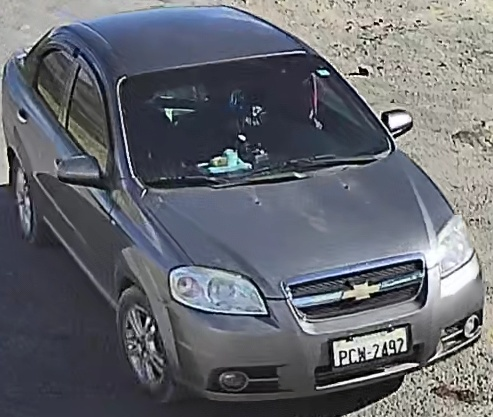

Evidencia: evidence/vehicles/EVT_(60)_0028_111_veh.jpg


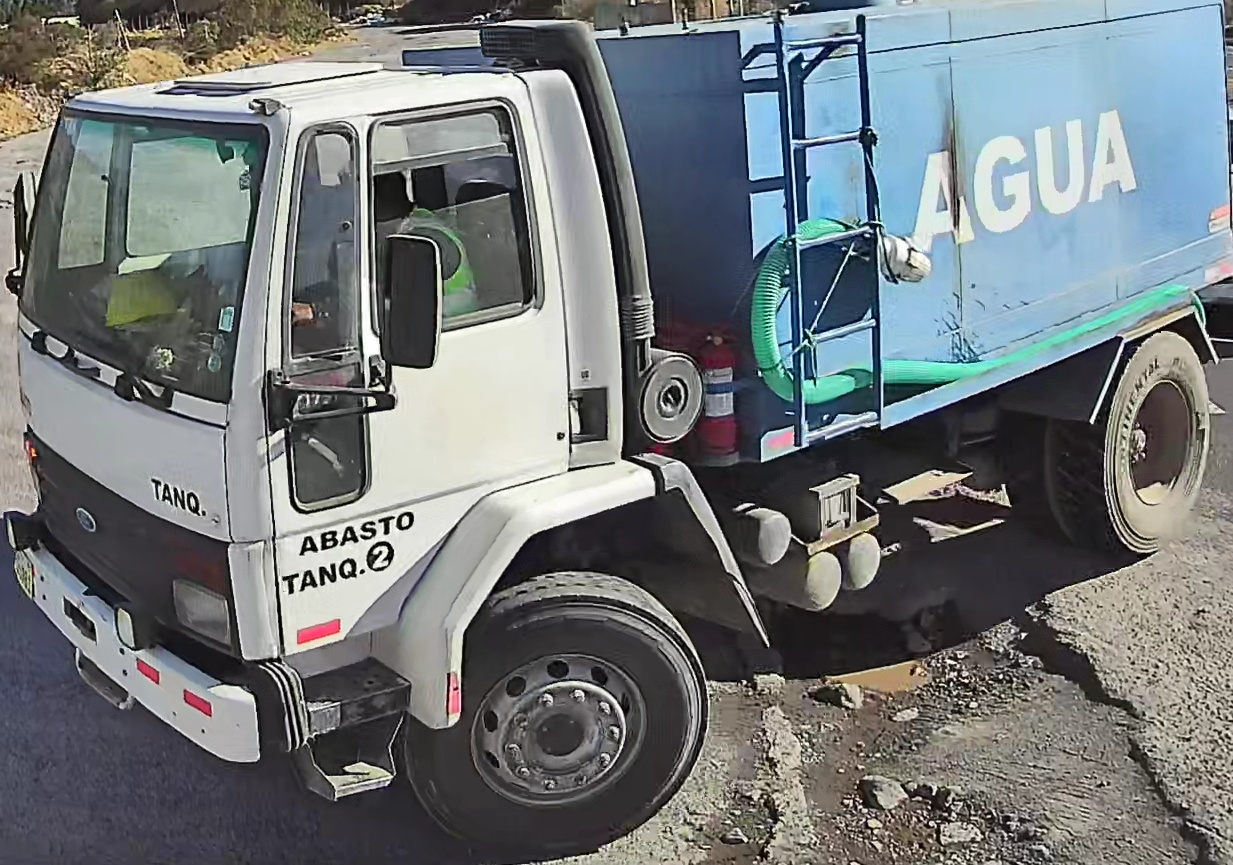

Evidencia: evidence/vehicles/EVT_(60)_0031_114_veh.jpg


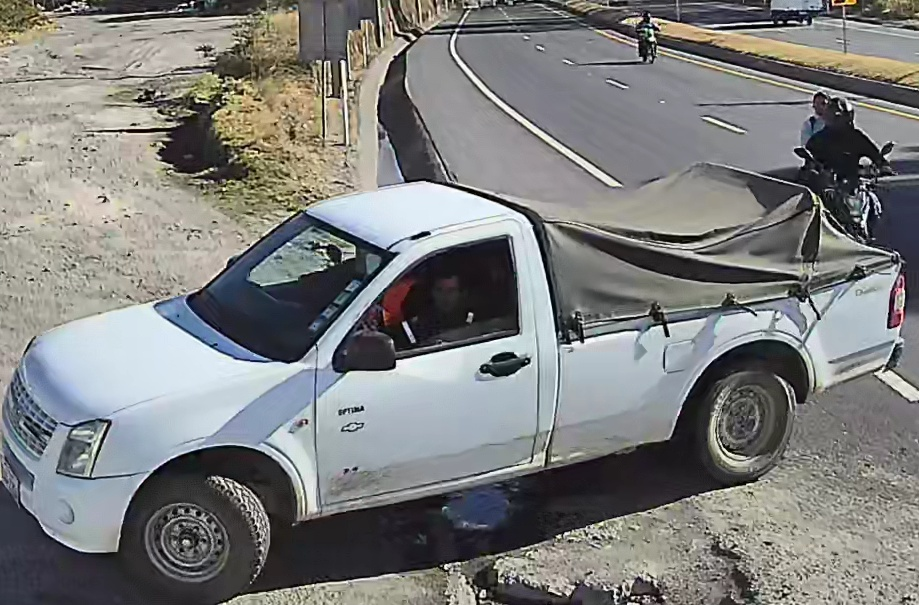

Evidencia: evidence/vehicles/EVT_(60)_0052_123_veh.jpg


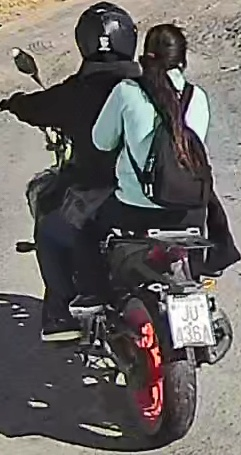

In [6]:
# 6. Galería de Evidencias (Fotos de Vehículos y Recortes de Placa)
import glob
from IPython.display import Image, display

veh_images = sorted(glob.glob("evidence/vehicles/*.jpg"))
print(f"Total fotos de vehículos guardadas: {len(veh_images)}")
for img_path in veh_images[:4]:
    print(f"Evidencia: {img_path}")
    display(Image(filename=img_path, width=400))

In [16]:
# 7. Descargar el Reporte Excel de Auditoría
try:
    from google.colab import files
    if os.path.exists("reports/reporte_auditoria.xlsx"):
        files.download("reports/reporte_auditoria.xlsx")
        print("📥 Descargando reporte_auditoria.xlsx...")
except Exception as e:
    print(f"Descarga manual disponible en reports/reporte_auditoria.xlsx: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Descargando reporte_auditoria.xlsx...


In [ ]:

    # 1. Comprobar capacidades de GPU y decodificadores disponibles en Colab
    !nvidia-smi
    !ffmpeg -hide_banner -hwaccels
    !ffmpeg -hide_banner -decoders | grep -Ei "h264_cuvid|hevc_cuvid|nvdec|cuvid"

    # 2. Copiar localmente el clip 60 para el benchmark puro
    import os, shutil
    os.makedirs("/content/videos_local", exist_ok=True)
    src_60 = "/content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4"
    dst_60 = "/content/videos_local/clip_60.mp4"
    if not os.path.exists(dst_60):
        shutil.copyfile(src_60, dst_60)
        print("✅ Clip 60 copiado a local.")

    # 3. Metadatos del códec
    !ffprobe -v error -select_streams v:0 -show_entries stream=codec_name,width,height,r_frame_rate,pix_fmt -of default=noprint_wrappers=1 /content/videos_local/clip_60.mp4

    # 4. BENCHMARK A: Decodificación CPU pura con FFmpeg
    print("\n--- BENCHMARK 1: CPU Decode ---")
    !ffmpeg -benchmark -v error -c:v hevc -i /content/videos_local/clip_60.mp4 -map 0:v:0 -f null -

    # 5. BENCHMARK B: Decodificación por Hardware GPU (CUDA/NVDEC)
    print("\n--- BENCHMARK 2: NVDEC CUDA Hardware Decode ---")
    !ffmpeg -benchmark -v error -hwaccel cuda -hwaccel_output_format cuda -i \
  /content/videos_local/clip_60.mp4 -map 0:v:0 -f null -

    # 6. BENCHMARK C: Decodificación explícita CUVID
    print("\n--- BENCHMARK 3: CUVID Decode ---")
    !ffmpeg -benchmark -v error -c:v hevc_cuvid -i /content/videos_local/clip_60.mp4 -map 0:v:0 -\
  f null -


Thu Sep 17 17:46:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import subprocess
import time

VIDEO = "/content/videos_local/clip_60.mp4"

def benchmark(name, cmd):
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    t0 = time.perf_counter()

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    elapsed = time.perf_counter() - t0

    print(f"Return code: {result.returncode}")
    print(f"WALL TIME: {elapsed:.3f} s")

    if result.returncode != 0:
        print("\n--- STDERR ---")
        print(result.stderr[-4000:])

    return elapsed


# ============================================================
# A) FFmpeg CPU HEVC decode
# ============================================================

cpu_time = benchmark(
    "1. CPU — HEVC software decode",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-f", "null",
        "-"
    ]
)


# ============================================================
# B) NVDEC automático vía CUDA
# Mantiene los frames en GPU
# ============================================================

nvdec_time = benchmark(
    "2. NVIDIA NVDEC — CUDA hwaccel",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-hwaccel", "cuda",
        "-hwaccel_output_format", "cuda",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-f", "null",
        "-"
    ]
)


# ============================================================
# C) Decoder HEVC CUVID explícito
# ============================================================

cuvid_time = benchmark(
    "3. NVIDIA HEVC_CUVID",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-c:v", "hevc_cuvid",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-f", "null",
        "-"
    ]
)


print("\n" + "=" * 70)
print("RESULTADOS")
print("=" * 70)

print(f"CPU:          {cpu_time:8.3f} s")
print(f"CUDA NVDEC:   {nvdec_time:8.3f} s")
print(f"HEVC CUVID:   {cuvid_time:8.3f} s")

if nvdec_time > 0:
    print(f"Speedup NVDEC vs CPU: {cpu_time/nvdec_time:.2f}x")

if cuvid_time > 0:
    print(f"Speedup CUVID vs CPU: {cpu_time/cuvid_time:.2f}x")


1. CPU — HEVC software decode
Return code: 0
WALL TIME: 164.057 s

2. NVIDIA NVDEC — CUDA hwaccel
Return code: 0
WALL TIME: 14.685 s

3. NVIDIA HEVC_CUVID
Return code: 0
WALL TIME: 21.132 s

RESULTADOS
CPU:           164.057 s
CUDA NVDEC:     14.685 s
HEVC CUVID:     21.132 s
Speedup NVDEC vs CPU: 11.17x
Speedup CUVID vs CPU: 7.76x


In [ ]:
download_time = benchmark(
    "4. NVDEC + transferencia GPU → CPU",
    [
        "ffmpeg",
        "-hide_banner",
        "-nostdin",
        "-loglevel", "error",
        "-hwaccel", "cuda",
        "-hwaccel_output_format", "cuda",
        "-i", VIDEO,
        "-map", "0:v:0",
        "-an", "-sn", "-dn",
        "-vf", "hwdownload,format=nv12",
        "-f", "null",
        "-"
    ]
)

print(f"NVDEC + GPU→CPU: {download_time:.3f} s")


4. NVDEC + transferencia GPU → CPU
Return code: 0
WALL TIME: 21.697 s
NVDEC + GPU→CPU: 21.697 s


In [ ]:
    !cd /content/PlacasVideos && git pull


remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.46 KiB | 748.00 KiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   c4681e1..e2425f9  main       -> origin/main
Updating c4681e1..e2425f9
Fast-forward
 src/video_decoder.py | 101 +++++++++++++++++++++++++++++++++++++++++----------
 1 file changed, 82 insertions(+), 19 deletions(-)


In [ ]:
    !python main.py "$VIDEOS_DIR" --clips 60 61


PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.2.0
Inicio de corrida: 2026-09-17 18:14:49
📹 Videos a procesar (2 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(61).mp4
Loading vehicle detector (YOLOv8n) on device='cuda'...
Loading FastALPR on providers=['CUDAExecutionProvider', 'CPUExecutionProvider'] (device='cuda')...
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)
⚡ [SSD Staging] Copiando Camara Placas 2_20260909105651-20260909163038(60).mp4 (251.8 MB) a NVMe SSD...
⚡ [SSD Staging] Listo en 0.58s (437.6 MB/s). Decodificando en SSD local.

[18:14:53] Starting video processing: Camara Placas 2_20260909105651-20260909163038(60).mp4 (Ref Time: 2026-09-09 16:17:20)
⚡ [VideoDecoder] Backend 'auto' -> Activando NVDEC (NVIDIA GPU Hardware Acceleration)
/content/PlacasVide

In [ ]:
!cd /content/PlacasVideos && git pull


Already up to date.


In [ ]:
!python benchmarks/diagnose_ab_decoders.py --full-pipeline


Traceback (most recent call last):
  File "/content/PlacasVideos/benchmarks/diagnose_ab_decoders.py", line 25, in <module>
    from src.pipeline_runner import ALPRPipeline
  File "/content/PlacasVideos/src/pipeline_runner.py", line 29, in <module>
    import supervision as sv
  File "/usr/local/lib/python3.13/dist-packages/supervision/__init__.py", line 10, in <module>
    from supervision.annotators.core import (
    ...<23 lines>...
    )
  File "/usr/local/lib/python3.13/dist-packages/supervision/annotators/core.py", line 10, in <module>
    from scipy.interpolate import splev, splprep
  File "/usr/local/lib/python3.13/dist-packages/scipy/interpolate/__init__.py", line 192, in <module>
    from ._interpolate import *
  File "/usr/local/lib/python3.13/dist-packages/scipy/interpolate/_interpolate.py", line 8, in <module>
    import scipy.special as spec
  File "/usr/local/lib/python3.13/dist-packages/scipy/special/__init__.py", line 784, in <module>
    from . import _ufuncs
  File "s

In [ ]:
!python main.py "/content/drive/MyDrive/Cam PL" --clips 60 61 --decoder nvdec

PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.3.0
Inicio de corrida: 2026-09-17 20:10:04
📹 Videos a procesar (2 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(61).mp4
Loading vehicle detector (YOLOv8n) on device='cuda'...
Loading FastALPR on providers=['CUDAExecutionProvider', 'CPUExecutionProvider'] (device='cuda')...
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)
⚡ [SSD Staging] Copiando Camara Placas 2_20260909105651-20260909163038(60).mp4 (251.8 MB) a NVMe SSD...
⚡ [SSD Staging] Listo en 0.54s (469.5 MB/s). Decodificando en SSD local.

[20:10:08] Starting video processing: Camara Placas 2_20260909105651-20260909163038(60).mp4 (Ref Time: 2026-09-09 16:17:20)
⚡ [VideoDecoder] Backend explícito: NVDEC
/content/PlacasVideos/src/pipeline_runner.py:204: FutureWarning

In [ ]:
!cd /content/PlacasVideos && git pull


remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 8 (delta 7), reused 8 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 1.93 KiB | 247.00 KiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   a6952b5..1cd850c  main       -> origin/main
Updating a6952b5..1cd850c
Fast-forward
 benchmarks/diagnose_ab_decoders.py | 23 ++++++++----
 main.py                            |  2 +-
 src/pipeline_runner.py             |  2 +-
 src/video_decoder.py               | 75 ++++++++++++++++++--------------------
 4 files changed, 53 insertions(+), 49 deletions(-)


In [ ]:
    !cd /content/PlacasVideos && git pull
    !python benchmarks/diagnose_ab_decoders.py

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 416 bytes | 208.00 KiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   b14034d..0b55a94  main       -> origin/main
Updating b14034d..0b55a94
Fast-forward
 benchmarks/diagnose_ab_decoders.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)
DIAGNÓSTICO COMPARATIVO A/B EXACTO: OpenCV vs NVDEC
Video: /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4

Loading vehicle detector (YOLOv8n) on device='cuda'...
Loading FastALPR on providers=['CUDAExecutionProvider', 'CPUExecutionProvider'] (device='cuda')...
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)
[OPENCV] Extrayendo frames en timestamps [25.0, 105.0, 109.0, 112.0, 1

In [ ]:
!python main.py "$VIDEOS_DIR" --clips 60 61


PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.4.0
Inicio de corrida: 2026-09-17 20:39:07
📹 Videos a procesar (2 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(61).mp4
Loading vehicle detector (YOLOv8n) on device='cuda'...
Loading FastALPR on providers=['CUDAExecutionProvider', 'CPUExecutionProvider'] (device='cuda')...
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)
⚡ [SSD Staging] Copiando Camara Placas 2_20260909105651-20260909163038(60).mp4 (251.8 MB) a NVMe SSD...
⚡ [SSD Staging] Listo en 0.53s (472.6 MB/s). Decodificando en SSD local.

[20:39:11] Starting video processing: Camara Placas 2_20260909105651-20260909163038(60).mp4 (Ref Time: 2026-09-09 16:17:20)
⚡ [VideoDecoder] Backend 'auto' -> Activando NVDEC (NVIDIA GPU Hardware Acceleration)
/content/PlacasVide

In [ ]:
!cd /content/PlacasVideos && git pull
!python benchmarks/benchmark_ffmpeg_nvdec.py

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 5.36 KiB | 127.00 KiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   716f875..1d9006b  main       -> origin/main
Updating 716f875..1d9006b
Fast-forward
 GoogleColab_ALPR_Pipeline.ipynb | 724 +++++++++++++++++++++++++++++-----------
 1 file changed, 530 insertions(+), 194 deletions(-)
BENCHMARK DE PIPELINES FFMPEG NVDEC (Clip 60: 8223 frames, 330.5s)
Video: /content/videos_local/clip_60.mp4

Testing: 1. NVDEC CUDA -> hwdownload -> NV12 (null sink)...
  ✅ SUCCESS: 21.69s | 379.0 fps (15.23x realtime)

Testing: 2. NVDEC CUDA -> hwdownload -> crop NV12 (2300x1064)...
  ✅ SUCCESS: 21.39s | 384.5 fps (15.45x realtime)

Testing: 3. NVDEC CUDA -> hwdownload -> crop NV12 -> pix_fmt bgr24 (v1.4.0)...
  ✅ SUCCESS: 94.50s | 87.0 fps (3.50x realtime)

Testing:

In [9]:
!cd /content/PlacasVideos && git pull


remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 8 (delta 6), reused 8 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 863 bytes | 123.00 KiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   ea04597..8d18e7d  main       -> origin/main
Updating ea04597..8d18e7d
Fast-forward
 config/camera_config.yaml |  2 +-
 main.py                   | 13 +++++++++----
 src/pipeline_runner.py    |  4 ++--
 src/video_decoder.py      |  6 +++---
 4 files changed, 15 insertions(+), 10 deletions(-)


In [10]:
!python main.py "$VIDEOS_DIR" --clips 60 61

PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.8.1
Inicio de corrida: 2026-09-17 22:02:36
📹 Videos a procesar (2 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(60).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(61).mp4
Loading vehicle detector (yolov8n.onnx) on device='cuda'...
Loading FastALPR on providers=['CUDAExecutionProvider', 'CPUExecutionProvider'] (device='cuda')...
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)
⚡ [SSD Staging] Copiando Camara Placas 2_20260909105651-20260909163038(60).mp4 (251.8 MB) a NVMe SSD...
⚡ [SSD Staging] Listo en 6.74s (37.4 MB/s). Decodificando en SSD local.
⚡ [SSD Staging] Copiando Camara Placas 2_20260909105651-20260909163038(61).mp4 (251.9 MB) a NVMe SSD...
⚡ [SSD Staging] Listo en 0.90s (280.9 MB/s). Decodificando en SSD local.

[22:02:48] Starting video processing: Camara Pla

In [14]:
 !cd /content/PlacasVideos && git pull


remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 10 (delta 6), reused 9 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 2.24 MiB | 14.58 MiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   99ab4e5..5c97d06  main       -> origin/main
Updating 99ab4e5..5c97d06
Fast-forward
 "Revisi\303\263n bypass Pintag.xlsx" | Bin 0 -> 2343622 bytes
 benchmarks/cross_validate_audit.py   | 282 +++++++++++++++++++++++++++++++++++
 main.py                              |  54 +++++--
 src/pipeline_runner.py               |   2 +-
 4 files changed, 326 insertions(+), 12 deletions(-)
 create mode 100644 "Revisi\303\263n bypass Pintag.xlsx"
 create mode 100644 benchmarks/cross_validate_audit.py


In [12]:
!python main.py "$VIDEOS_DIR" --limit 5


PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.8.1
Inicio de corrida: 2026-09-17 22:09:39
📹 Videos a procesar (5 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(1).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(2).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(3).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(4).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(5).mp4
Loading vehicle detector (yolov8n.onnx) on device='cuda'...
Loading FastALPR on providers=['CUDAExecutionProvider', 'CPUExecutionProvider'] (device='cuda')...
INFO:open_image_models.detection.core.yolo_v9.inference:Using ONNX Runtime with ['CUDAExecutionProvider', 'CPUExecutionProvider'] provider(s)
⚡ [SSD Staging] Copiando Camara Placas 2_20260909105651-20260909163038(1).mp4 (30.0 MB) a NVMe SSD...
⚡ [SSD Staging] Listo en 0.18s (170.7 MB/

In [15]:
!python main.py "$VIDEOS_DIR" --limit 10


PIPELINE ALPR LIGERO ORIENTADO A EVENTOS v1.8.2
Inicio de corrida: 2026-09-17 22:26:33
📹 Videos a procesar (10 archivos):
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(1).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(2).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(3).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(4).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(5).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(6).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(7).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(8).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(9).mp4
  - /content/drive/MyDrive/Cam PL/Camara Placas 2_20260909105651-20260909163038(10).mp4
Loading

In [17]:
    !git pull
    !python benchmarks/resumen_ejecutivo.py

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 3.12 KiB | 3.12 MiB/s, done.
From https://github.com/riofutabac/PlacasVideos
   5c97d06..3691e6e  main       -> origin/main
Updating 5c97d06..3691e6e
Fast-forward
 benchmarks/resumen_ejecutivo.py | 195 ++++++++++++++++++++++++++++++++++++++++
 1 file changed, 195 insertions(+)
 create mode 100644 benchmarks/resumen_ejecutivo.py

╔══════════════════════════════════════════════════════════════════════╗
║           RESUMEN EJECUTIVO DE RENDIMIENTO - PIPELINE ALPR           ║
╚══════════════════════════════════════════════════════════════════════╝

📌 Identificador de Corrida:  RUN_20260917_222638
🕒 Inicio: 2026-09-17 22:26:38  |  Fin: 2026-09-17 22:33:33
📁 Clips de video procesados: 9 archivos (resolución 3K: 2960×1664)

───────────────────────────────────────────